# Notebook 05 — Lasso under multiple evaluation strategies

**Goal:** Re-evaluate the Lasso baseline (from Notebook 03) under three additional
cross-validation strategies, as requested by Prof. Lüdtke in the May 2026 meeting.
Random 5-fold CV alone overestimates performance because of temporal autocorrelation
(samples from adjacent days at the same site are very similar).

**Setup:**
- Pipeline: `StandardScaler → LassoCV` (α selected by inner 5-fold CV on the training fold).
- Targets: temperature, salinity, Chl_a_log1p (column produced in Notebook 02).
- Inputs: 16S clean, 18S clean, combined 16S+18S.

**Output:** `results/phase1_lasso_3targets_3inputs_4strategies.csv`

In [3]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd

# Make src/ importable
sys.path.insert(0, str(Path("..").resolve()))

from src.cv_strategies import (
    random_kfold,
    temporal_holdout,
    temporal_blocked_kfold,
    leave_one_site_out,
)
from src.lasso_evaluator import run_lasso_with_splits

print("All imports OK")

All imports OK


In [4]:
# Load all cleaned tables produced by Notebook 02 (with log1p applied)
PROCESSED_DIR = Path("../data/processed")

meta    = pd.read_csv(PROCESSED_DIR / "meta_clean.csv",    index_col=0)
otu_16s = pd.read_csv(PROCESSED_DIR / "otu_16s_clean.csv", index_col=0)
otu_18s = pd.read_csv(PROCESSED_DIR / "otu_18s_clean.csv", index_col=0)

# Build combined matrix (same as in Notebook 03)
otu_combined = pd.concat([otu_16s, otu_18s], axis=1)

# Sanity checks
assert (meta.index == otu_16s.index).all(),  "meta vs 16S misaligned"
assert (meta.index == otu_18s.index).all(),  "meta vs 18S misaligned"
assert otu_combined.columns.is_unique,        "duplicate columns in combined"
assert 'Chl_a_log1p' in meta.columns,         "Chl_a_log1p column missing — re-run Notebook 02"

print(f"meta:         {meta.shape}")
print(f"otu_16s:      {otu_16s.shape}")
print(f"otu_18s:      {otu_18s.shape}")
print(f"otu_combined: {otu_combined.shape}")
print(f"\n✓ All tables aligned.")
print(f"✓ Chl_a_log1p column is available in meta.")

meta:         (1538, 24)
otu_16s:      (1538, 1236)
otu_18s:      (1538, 1054)
otu_combined: (1538, 2290)

✓ All tables aligned.
✓ Chl_a_log1p column is available in meta.


In [6]:
# ---- Experiment configuration ----
RANDOM_SEED = 42

# Map (target_column, log_target_flag) for each target.
# For Chl_a we use the pre-transformed Chl_a_log1p column from Notebook 02,
# so log_target=False here (the log is already done).
TARGETS = [
    {'name': 'temperature',   'col': 'temperature',  'log': False},
    {'name': 'salinity',      'col': 'salinity',     'log': False},
    {'name': 'Chl_a (log1p)', 'col': 'Chl_a_log1p',  'log': False},
]

# Map input name → DataFrame
INPUTS = {
    '16S':     otu_16s,
    '18S':     otu_18s,
    '16S+18S': otu_combined,
}

# The 3 new strategies we'll run in this notebook.
# Random K-fold is excluded — we already have those numbers from Notebook 03.
STRATEGIES = ['temporal_holdout', 'temporal_blocked_kfold', 'leave_one_site_out']

# All results will accumulate here, one row per (target × input × strategy) cell
all_rows = []

print(f"Random seed:   {RANDOM_SEED}")
print(f"Targets ({len(TARGETS)}):    {[t['name'] for t in TARGETS]}")
print(f"Inputs ({len(INPUTS)}):     {list(INPUTS.keys())}")
print(f"Strategies ({len(STRATEGIES)}): {STRATEGIES}")
print(f"\nTotal new runs to do: {len(TARGETS) * len(INPUTS) * len(STRATEGIES)} = "
      f"{len(TARGETS)} × {len(INPUTS)} × {len(STRATEGIES)}")

Random seed:   42
Targets (3):    ['temperature', 'salinity', 'Chl_a (log1p)']
Inputs (3):     ['16S', '18S', '16S+18S']
Strategies (3): ['temporal_holdout', 'temporal_blocked_kfold', 'leave_one_site_out']

Total new runs to do: 27 = 3 × 3 × 3


In [6]:
def build_splits(strategy_name, meta_valid, random_seed=42):
    """
    Dispatch to the right cv_strategies function based on strategy name.
    Returns a list of (train_idx, test_idx) tuples — indices into meta_valid.
    """
    n = len(meta_valid)

    if strategy_name == 'random_kfold':
        return random_kfold(n_samples=n, n_folds=5, random_seed=random_seed)

    elif strategy_name == 'temporal_holdout':
        return temporal_holdout(meta_valid, test_fraction=0.2)

    elif strategy_name == 'temporal_blocked_kfold':
        return temporal_blocked_kfold(meta_valid, n_folds=5)

    elif strategy_name == 'leave_one_site_out':
        return leave_one_site_out(meta_valid)

    else:
        raise ValueError(f"Unknown strategy: {strategy_name}")


# Quick test on temperature × 16S to confirm dispatch works
_test_valid_mask = meta['temperature'].notna()
_test_meta_valid = meta.loc[_test_valid_mask].reset_index(drop=True)
print("Quick dispatch test on temperature target:")
for s in STRATEGIES:
    splits = build_splits(s, _test_meta_valid, RANDOM_SEED)
    print(f"  {s:30s}  →  {len(splits)} folds")

Quick dispatch test on temperature target:
  temporal_holdout                →  1 folds
  temporal_blocked_kfold          →  5 folds
  leave_one_site_out              →  14 folds


In [7]:
# Main experiment loop: 3 targets × 3 inputs × 3 strategies = 27 runs

t_global_start = time.time()
run_counter = 0
total_runs = len(TARGETS) * len(INPUTS) * len(STRATEGIES)

for target_spec in TARGETS:
    target_name  = target_spec['name']
    target_col   = target_spec['col']
    log_flag     = target_spec['log']

    for input_name, otu_df in INPUTS.items():
        # Filter to valid samples for this target, keep meta and otu aligned
        valid_mask = meta[target_col].notna()
        meta_valid = meta.loc[valid_mask].reset_index(drop=True)
        otu_valid  = otu_df.loc[valid_mask].reset_index(drop=True)

        for strategy_name in STRATEGIES:
            run_counter += 1
            print(f"\n{'#' * 64}")
            print(f"# Run {run_counter}/{total_runs}  ·  "
                  f"target={target_name}  input={input_name}  strategy={strategy_name}")
            print(f"{'#' * 64}")

            splits = build_splits(strategy_name, meta_valid, RANDOM_SEED)

            res = run_lasso_with_splits(
                target_name   = target_col,
                meta          = meta_valid,
                otu           = otu_valid,
                splits        = splits,
                strategy_name = strategy_name,
                input_name    = input_name,
                log_target    = log_flag,
                random_seed   = RANDOM_SEED,
                verbose       = True,
            )

            # Use the display name (e.g. 'Chl_a (log1p)') for the results row,
            # not the column name ('Chl_a_log1p')
            res['target_display'] = target_name
            all_rows.append(res)

t_global_end = time.time()
print(f"\n{'=' * 64}")
print(f"All {total_runs} runs complete in {(t_global_end - t_global_start) / 60:.1f} minutes.")
print(f"Collected {len(all_rows)} result dicts in `all_rows`.")


################################################################
# Run 1/27  ·  target=temperature  input=16S  strategy=temporal_holdout
################################################################

  Lasso · input=16S · target=temperature · strategy=temporal_holdout
  Samples: 1223    Features: 1236    Folds: 1
    Fold  1: R²=-16.3173  MAE= 5.807  α=0.0301  feat=295  time=505.9s

  Summary:
    R²:   -16.3173  ±  0.0000
    MAE:  5.807  ±  0.000
    Mean α:              0.0301
    Mean features used:  295 / 1236
    Total CV time:       505.9s

################################################################
# Run 2/27  ·  target=temperature  input=16S  strategy=temporal_blocked_kfold
################################################################

  Lasso · input=16S · target=temperature · strategy=temporal_blocked_kfold
  Samples: 1223    Features: 1236    Folds: 5


/mnt/data/home/tv2414/miniconda3/envs/thesis/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.002e+00, tolerance: 2.866e+00
  model = cd_fast.enet_coordinate_descent(


    Fold  1: R²=-25.4008  MAE=11.516  α=0.0333  feat=260  time=1137.2s
    Fold  2: R²=-54.8642  MAE=12.486  α=0.0187  feat=345  time=329.4s
    Fold  3: R²=-0.1223  MAE= 3.297  α=0.0831  feat=155  time=713.8s
    Fold  4: R²=-19.3522  MAE= 4.226  α=0.0449  feat=225  time=502.8s
    Fold  5: R²=-10.9857  MAE= 5.335  α=0.0300  feat=290  time=709.2s

  Summary:
    R²:   -22.1450  ±  18.4308
    MAE:  7.372  ±  3.847
    Mean α:              0.0420
    Mean features used:  255 / 1236
    Total CV time:       3392.4s

################################################################
# Run 3/27  ·  target=temperature  input=16S  strategy=leave_one_site_out
################################################################

  Lasso · input=16S · target=temperature · strategy=leave_one_site_out
  Samples: 1223    Features: 1236    Folds: 14
    Fold  1: R²= 0.7302  MAE= 2.320  α=0.1399  feat=128  time=620.1s
    Fold  2: R²= 0.5179  MAE= 2.905  α=0.1519  feat=124  time=638.6s
    Fold  3: R²= 0

/mnt/data/home/tv2414/miniconda3/envs/thesis/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.430e+00, tolerance: 3.713e+00
  model = cd_fast.enet_coordinate_descent(


    Fold  4: R²= 0.6452  MAE= 2.563  α=0.1512  feat=124  time=868.4s


...

    Fold 12: R²=-0.7399  MAE= 0.762  α=0.0236  feat=90  time=293.0s


/mnt/data/home/tv2414/miniconda3/envs/thesis/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.131e-01, tolerance: 1.070e-01
  model = cd_fast.enet_coordinate_descent(
/mnt/data/home/tv2414/miniconda3/envs/thesis/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.367e-01, tolerance: 1.005e-01
  model = cd_fast.enet_coordinate_descent(
/mnt/data/home/tv2414/miniconda3/envs/thesis/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

    Fold 13: R²=-0.4133  MAE= 0.356  α=0.0191  feat=135  time=209.1s


/mnt/data/home/tv2414/miniconda3/envs/thesis/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.080e-02, tolerance: 6.497e-02
  model = cd_fast.enet_coordinate_descent(
/mnt/data/home/tv2414/miniconda3/envs/thesis/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.303e-01, tolerance: 1.082e-01
  model = cd_fast.enet_coordinate_descent(


    Fold 14: R²=-0.4682  MAE= 0.396  α=0.0193  feat=129  time=193.7s

  Summary:
    R²:   -3.1748  ±  11.0515
    MAE:  0.589  ±  0.582
    Mean α:              0.0175
    Mean features used:  141 / 1236
    Total CV time:       4090.6s

################################################################
# Run 22/27  ·  target=Chl_a (log1p)  input=18S  strategy=temporal_holdout
################################################################

  Lasso · input=18S · target=Chl_a_log1p · strategy=temporal_holdout
  Samples: 1437    Features: 1054    Folds: 1
    Fold  1: R²=-1.7033  MAE= 0.840  α=0.0040  feat=454  time=45.7s

  Summary:
    R²:   -1.7033  ±  0.0000
    MAE:  0.840  ±  0.000
    Mean α:              0.0040
    Mean features used:  454 / 1054
    Total CV time:       45.7s

################################################################
# Run 23/27  ·  target=Chl_a (log1p)  input=18S  strategy=temporal_blocked_kfold
###########################################################

In [8]:
# Save all 27 new runs to CSV, plus combine with the random_kfold results
# from Notebook 03 to build the complete 4-strategy table.

# Build DataFrame from the new runs
new_results = pd.DataFrame(all_rows)

# Use target_display for clean labels in the output
new_results['target'] = new_results['target_display']
new_results = new_results.drop(columns=['target_display'])

# Reorder columns for readability
col_order = ['strategy', 'input', 'target', 'n_folds', 'n_samples', 'n_features',
             'r2_mean', 'r2_std', 'mae_mean', 'mae_std', 'rmse_mean', 'rmse_std',
             'alpha_mean', 'n_selected_mean', 'total_time']
new_results = new_results[col_order]

# Round for readability
new_results = new_results.round({
    'r2_mean': 4, 'r2_std': 4,
    'mae_mean': 3, 'mae_std': 3,
    'rmse_mean': 3, 'rmse_std': 3,
    'alpha_mean': 4, 'n_selected_mean': 1, 'total_time': 1,
})

# Save raw new results
new_out = Path("../results/phase1_lasso_3newstrategies.csv")
new_results.to_csv(new_out, index=False)
print(f"Saved 27 new runs to: {new_out}\n")

# Print summary table for quick inspection
print(new_results.to_string(index=False))

Saved 27 new runs to: ../results/phase1_lasso_3newstrategies.csv

              strategy   input        target  n_folds  n_samples  n_features    r2_mean    r2_std  mae_mean  mae_std  rmse_mean  rmse_std  alpha_mean  n_selected_mean  total_time
      temporal_holdout     16S   temperature        1       1223        1236   -16.3173    0.0000     5.807    0.000      9.473     0.000      0.0301            295.0       505.9
temporal_blocked_kfold     16S   temperature        5       1223        1236   -22.1450   18.4308     7.372    3.847     12.228     8.048      0.0420            255.0      3392.4
    leave_one_site_out     16S   temperature       14       1223        1236     0.6005    0.2504     2.768    0.686      3.866     1.216      0.1499            124.4     10995.8
      temporal_holdout     18S   temperature        1       1223        1054   -95.1117    0.0000    10.773    0.000     22.316     0.000      0.0226            417.0       126.5
temporal_blocked_kfold     18S   temper

In [9]:
# ---- Step 1: Load the random_kfold results from Notebook 03 ----
old_results = pd.read_csv("../results/phase1_lasso_3targets_3inputs_with_alpha.csv")

# Filter out the Chl_a "none" row (broken baseline) — we only want the log1p version
# for direct comparison with the new strategies (which all use Chl_a_log1p)
old_results = old_results[
    ~((old_results['target'] == 'Chl_a') & (old_results['transform'] == 'none'))
].copy()

# Map the old schema to the new one (add strategy, n_folds, fill missing cols)
old_results['strategy'] = 'random_kfold'
old_results['n_folds']  = 5
# Use display names matching the new runs
old_results.loc[old_results['target'] == 'Chl_a', 'target'] = 'Chl_a (log1p)'

# Rename to match new schema
old_results = old_results.rename(columns={
    'features_used': 'n_selected_mean',
})

# Add missing columns (the old runs didn't track these)
for col in ['mae_std', 'rmse_mean', 'rmse_std', 'total_time']:
    if col not in old_results.columns:
        old_results[col] = np.nan

# Keep only the columns we need, in the right order
keep_cols = ['strategy', 'input', 'target', 'n_folds', 'n_samples', 'n_features',
             'r2_mean', 'r2_std', 'mae_mean', 'mae_std', 'rmse_mean', 'rmse_std',
             'alpha_mean', 'n_selected_mean', 'total_time']
old_results = old_results[keep_cols]

print(f"Loaded {len(old_results)} random_kfold rows from Notebook 03.\n")

# ---- Step 2: Concatenate old + new ----
all_strategies = pd.concat([old_results, new_results], ignore_index=True)

# Sort for readability: by target, then input, then strategy
strategy_order = ['random_kfold', 'temporal_holdout', 'temporal_blocked_kfold', 'leave_one_site_out']
input_order    = ['16S', '18S', '16S+18S']
target_order   = ['temperature', 'salinity', 'Chl_a (log1p)']

all_strategies['strategy'] = pd.Categorical(all_strategies['strategy'], categories=strategy_order, ordered=True)
all_strategies['input']    = pd.Categorical(all_strategies['input'],    categories=input_order,    ordered=True)
all_strategies['target']   = pd.Categorical(all_strategies['target'],   categories=target_order,   ordered=True)
all_strategies = all_strategies.sort_values(['target', 'input', 'strategy']).reset_index(drop=True)

# ---- Step 3: Save ----
out_path = Path("../results/phase1_lasso_3targets_3inputs_4strategies.csv")
all_strategies.to_csv(out_path, index=False)
print(f"Saved comprehensive table ({len(all_strategies)} rows) to: {out_path}\n")

# ---- Step 4: Print a focused summary table for inspection ----
# Just the key columns, no NaNs in display
summary = all_strategies[['target', 'input', 'strategy', 'r2_mean', 'r2_std', 'mae_mean']].copy()
summary = summary.round({'r2_mean': 4, 'r2_std': 4, 'mae_mean': 3})
print(summary.to_string(index=False))

Loaded 9 random_kfold rows from Notebook 03.

Saved comprehensive table (36 rows) to: ../results/phase1_lasso_3targets_3inputs_4strategies.csv

       target   input               strategy    r2_mean    r2_std  mae_mean
  temperature     16S           random_kfold     0.6746    0.0584     2.578
  temperature     16S       temporal_holdout   -16.3173    0.0000     5.807
  temperature     16S temporal_blocked_kfold   -22.1450   18.4308     7.372
  temperature     16S     leave_one_site_out     0.6005    0.2504     2.768
  temperature     18S           random_kfold     0.7500    0.1135     1.913
  temperature     18S       temporal_holdout   -95.1117    0.0000    10.773
  temperature     18S temporal_blocked_kfold  -214.3508  273.4982    13.183
  temperature     18S     leave_one_site_out    -0.6217    4.4138     2.671
  temperature 16S+18S           random_kfold     0.8368    0.0236     1.705
  temperature 16S+18S       temporal_holdout   -44.9346    0.0000     7.835
  temperature 16S+18

In [10]:
# Per-fold R² values for all 9 LOSO runs (extracted from the notebook output above).
# Site order matches cv_strategies.leave_one_site_out (alphabetical by location_name),
# which is also the order printed in the test cell at the start of the notebook.

site_names = [
    'Boergerende Strand',           # Fold 1
    'Diedrichshagen',                # Fold 2
    'Elmenhorst Strand',             # Fold 3
    'Jemnitzschleuse',               # Fold 4
    'Mittelmole Warnemuende',        # Fold 5
    'Muehlendamm',                   # Fold 6  ⚠️ suspected outlier
    'Neptun-Werft',                  # Fold 7
    'Parkplatz zur Warnow',          # Fold 8
    'SAB Marina Bramow',             # Fold 9
    'Schmarl-Dorf / IGA-Park',       # Fold 10
    'Schwimmhalle Gehlsdorf',        # Fold 11
    'Stadthafen Rostock',            # Fold 12
    'Steilkueste Nienhagen',         # Fold 13
    'Warnemuende Strand',            # Fold 14
]

# Per-fold R² lists, keyed by (target, input)
loso_fold_r2 = {
    ('temperature',    '16S'):     [ 0.7302,  0.5179,  0.7515,  0.6452,  0.6021,  -0.2715,  0.6250,  0.7335,  0.7231,  0.7509,  0.6928,  0.6588,  0.6166,  0.6306],
    ('temperature',    '18S'):     [ 0.5103,  0.7633,  0.7964,  0.6949,  0.6959, -16.4791, -0.2546,  0.8712,  0.7549,  0.8878,  0.8148,  0.7808,  0.7727, -0.3133],
    ('temperature',    '16S+18S'): [ 0.8491,  0.8013,  0.8631,  0.8432,  0.6432,  -3.5769,  0.7085,  0.8699,  0.8225,  0.9199,  0.8282,  0.7570,  0.9019,  0.8744],
    ('salinity',       '16S'):     [ 0.5271,  0.4827,  0.5758,  0.5250,  0.4980, -629.1394, 0.3809,  0.7162,  0.7243,  0.8208,  0.7029,  0.5759,  0.4991,  0.3204],
    ('salinity',       '18S'):     [ 0.5408,  0.5868,  0.6322, -1.7737, -0.5075, -21463.8958, 0.3480, 0.7655, 0.7423, 0.8251, 0.4787,  0.7609,  0.3962,  0.6388],
    ('salinity',       '16S+18S'): [ 0.6799,  0.7308,  0.6761,  0.6179, -1.0273, -24207.7466, 0.7084, 0.8366, 0.7833, 0.8904, 0.7825,  0.6360,  0.6680,  0.1131],
    ('Chl_a (log1p)',  '16S'):     [ 0.0574, -1.0013, -0.2528, -0.4301, -0.0829, -42.9888,  0.1575,  0.5312,  0.4463,  0.4553,  0.2820, -0.7399, -0.4133, -0.4682],
    ('Chl_a (log1p)',  '18S'):     [-0.1476, -0.0607, -0.3025, -0.6970, -0.3140,  -5.0180, -0.2992,  0.2889,  0.4792,  0.5427,  0.6251,  0.2630,  0.1620, -0.0381],
    ('Chl_a (log1p)',  '16S+18S'): [ 0.0963, -0.1947, -0.1939, -0.0775, -0.2743, -25.6852, -5.6215,  0.5316,  0.5795,  0.5805,  0.6131, -0.3554,  0.2635, -0.3662],
}

# Compute robust statistics for each LOSO run
robust_rows = []
MUEHL_IDX = 5  # zero-based index of Muehlendamm in the site order

for (target, inp), fold_r2 in loso_fold_r2.items():
    arr = np.array(fold_r2)
    arr_no_muehl = np.delete(arr, MUEHL_IDX)

    worst_idx = int(np.argmin(arr))

    robust_rows.append({
        'target':                       target,
        'input':                        inp,
        'r2_mean_all':                  float(arr.mean()),
        'r2_median_all':                float(np.median(arr)),
        'r2_q25':                       float(np.percentile(arr, 25)),
        'r2_q75':                       float(np.percentile(arr, 75)),
        'r2_min':                       float(arr.min()),
        'worst_site':                   site_names[worst_idx],
        'n_sites_r2_negative':          int((arr < 0).sum()),
        'r2_mean_excl_Muehlendamm':     float(arr_no_muehl.mean()),
        'r2_median_excl_Muehlendamm':   float(np.median(arr_no_muehl)),
    })

loso_robust = pd.DataFrame(robust_rows).round(3)

# Save
out_path = Path("../results/phase1_lasso_loso_robust_stats.csv")
loso_robust.to_csv(out_path, index=False)
print(f"Saved: {out_path}\n")

# Print headline columns
display_cols = ['target', 'input',
                'r2_mean_all', 'r2_median_all',
                'worst_site', 'n_sites_r2_negative',
                'r2_mean_excl_Muehlendamm']
print(loso_robust[display_cols].to_string(index=False))

Saved: ../results/phase1_lasso_loso_robust_stats.csv

       target   input  r2_mean_all  r2_median_all  worst_site  n_sites_r2_negative  r2_mean_excl_Muehlendamm
  temperature     16S        0.600          0.652 Muehlendamm                    1                     0.668
  temperature     18S       -0.622          0.759 Muehlendamm                    3                     0.598
  temperature 16S+18S        0.508          0.836 Muehlendamm                    1                     0.822
     salinity     16S      -44.414          0.526 Muehlendamm                    1                     0.565
     salinity     18S    -1532.819          0.564 Muehlendamm                    3                     0.341
     salinity 16S+18S    -1728.618          0.678 Muehlendamm                    2                     0.546
Chl_a (log1p)     16S       -3.175         -0.168 Muehlendamm                    8                    -0.112
Chl_a (log1p)     18S       -0.323         -0.049 Muehlendamm             

In [11]:
# Investigation: why is Muehlendamm consistently the worst-predicted site?
# Compare its distributions of targets and its geographic position to the
# other 13 sites.

MUEHL = 'Muehlendamm'

# ---- 1. Sample count and geographic info ----
print("=" * 64)
print(f"Site investigation: {MUEHL}")
print("=" * 64)

muehl_mask = meta['location_name'] == MUEHL
print(f"\nSamples at Muehlendamm:        {muehl_mask.sum()}")
print(f"Samples at the other 13 sites: {(~muehl_mask).sum()}")

# Geographic info — does meta have lat/lon?
geo_cols = [c for c in meta.columns if any(k in c.lower() for k in ['lat', 'lon', 'rough'])]
print(f"\nAvailable geographic columns: {geo_cols}")

if 'rough_lat_long' in meta.columns:
    muehl_geo = meta.loc[muehl_mask, 'rough_lat_long'].unique()
    print(f"\nMuehlendamm rough_lat_long: {muehl_geo}")
    print(f"\nAll sites' rough_lat_long:")
    for site, geo in meta.groupby('location_name')['rough_lat_long'].first().items():
        marker = "  ⚠️" if site == MUEHL else ""
        print(f"  {site:30s}  {geo}{marker}")

# ---- 2. Target distributions ----
print("\n" + "=" * 64)
print("Target distributions: Muehlendamm vs the other 13 sites")
print("=" * 64)

for target_col, label in [('temperature', 'Temperature (°C)'),
                           ('salinity',    'Salinity (PSU)'),
                           ('Chl_a',       'Chl_a (raw)')]:
    muehl_vals = meta.loc[muehl_mask, target_col].dropna()
    other_vals = meta.loc[~muehl_mask, target_col].dropna()

    print(f"\n{label}:")
    print(f"  {'':18s}  {'Muehlendamm':>14s}    {'Other 13 sites':>14s}")
    print(f"  {'min':18s}  {muehl_vals.min():>14.3f}    {other_vals.min():>14.3f}")
    print(f"  {'25th percentile':18s}  {muehl_vals.quantile(0.25):>14.3f}    {other_vals.quantile(0.25):>14.3f}")
    print(f"  {'median':18s}  {muehl_vals.median():>14.3f}    {other_vals.median():>14.3f}")
    print(f"  {'75th percentile':18s}  {muehl_vals.quantile(0.75):>14.3f}    {other_vals.quantile(0.75):>14.3f}")
    print(f"  {'max':18s}  {muehl_vals.max():>14.3f}    {other_vals.max():>14.3f}")
    print(f"  {'n samples':18s}  {len(muehl_vals):>14d}    {len(other_vals):>14d}")

# ---- 3. Salinity overlap check (key for understanding LOSO failure) ----
print("\n" + "=" * 64)
print("Critical check: does Muehlendamm's salinity range OVERLAP with the others?")
print("=" * 64)

muehl_sal = meta.loc[muehl_mask, 'salinity'].dropna()
other_sal = meta.loc[~muehl_mask, 'salinity'].dropna()

muehl_min, muehl_max = muehl_sal.min(), muehl_sal.max()
other_min, other_max = other_sal.min(), other_sal.max()

print(f"\nMuehlendamm salinity range:   [{muehl_min:.2f},  {muehl_max:.2f}]")
print(f"Other 13 sites range:         [{other_min:.2f},  {other_max:.2f}]")

# How many Muehlendamm samples lie outside the others' range?
outside_low  = (muehl_sal < other_min).sum()
outside_high = (muehl_sal > other_max).sum()
print(f"\nMuehlendamm samples below other sites' minimum: {outside_low}")
print(f"Muehlendamm samples above other sites' maximum: {outside_high}")
if outside_low + outside_high > 0:
    print(f"→ {outside_low + outside_high} of {len(muehl_sal)} Muehlendamm samples "
          f"are OUTSIDE the salinity range the model ever saw during training.")
    print("  This is a textbook case of out-of-distribution test data —")
    print("  Lasso cannot extrapolate, so predictions blow up.")
else:
    print("→ Muehlendamm's salinity is within the training range. The problem is")
    print("  in the input features (ASVs), not the target.")

Site investigation: Muehlendamm

Samples at Muehlendamm:        109
Samples at the other 13 sites: 1429

Available geographic columns: ['rough_lat_long']

Muehlendamm rough_lat_long: <StringArray>
['[54.0841494398656, 12.151006424457755]']
Length: 1, dtype: str

All sites' rough_lat_long:
  Boergerende Strand              [54.151487171879495, 11.886362440876928]
  Diedrichshagen                  [54.17711573457156, 12.027456126500924]
  Elmenhorst Strand               [54.17548962669349, 11.997652914250816]
  Jemnitzschleuse                 [54.147885248440694, 11.868971110779253]
  Mittelmole Warnemuende          [54.17791614479983, 12.092821864789912]
  Muehlendamm                     [54.0841494398656, 12.151006424457755]  ⚠️
  Neptun-Werft                    [54.155207965581155, 12.092080087646025]
  Parkplatz zur Warnow            [54.13159491098976, 12.097383290174285]
  SAB Marina Bramow               [54.11056226317913, 12.09354886530469]
  Schmarl-Dorf / IGA-Park         [54.1

Saved figure: ../results/phase1_lasso_heatmap.png


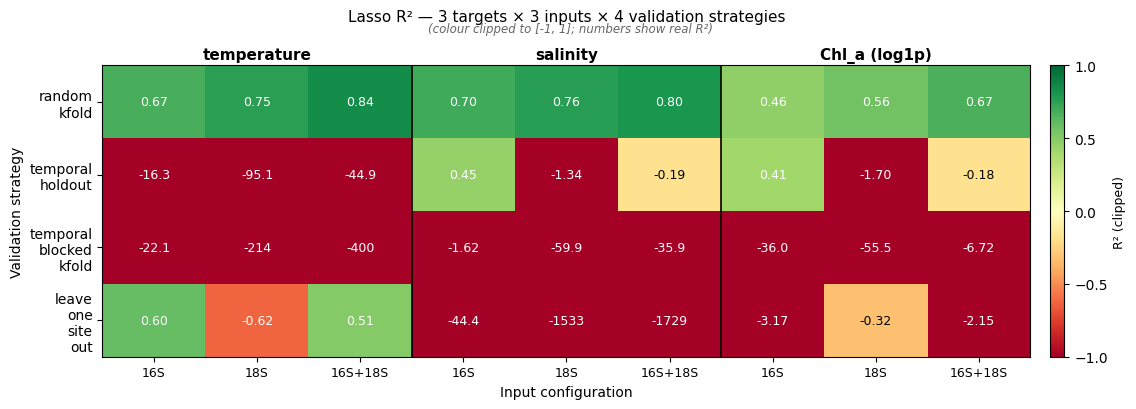

In [13]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

pivot = all_strategies.pivot_table(
    index='strategy',
    columns=['target', 'input'],
    values='r2_mean',
    observed=False,
)
pivot = pivot.reindex(index=strategy_order)
pivot = pivot.reindex(columns=pd.MultiIndex.from_product(
    [target_order, input_order], names=['target', 'input']
))

clip_min, clip_max = -1.0, 1.0
pivot_for_color = pivot.clip(lower=clip_min, upper=clip_max)

fig, ax = plt.subplots(figsize=(11.5, 4.2))

cmap = plt.get_cmap('RdYlGn')
norm = mcolors.TwoSlopeNorm(vmin=clip_min, vcenter=0.0, vmax=clip_max)
im = ax.imshow(pivot_for_color.values, aspect='auto', cmap=cmap, norm=norm)

# y-axis: strategy names
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels([s.replace('_', '\n') for s in pivot.index], fontsize=10)

# x-axis: input config labels
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels([inp for (_, inp) in pivot.columns], fontsize=9)

# Target group headers (placed close to top of cells, well clear of the title)
for i, target in enumerate(target_order):
    center_x = i * 3 + 1
    ax.text(center_x, -0.65, target, ha='center', va='center',
            fontsize=11, fontweight='bold')

# Vertical separators between target groups
for i in range(1, len(target_order)):
    ax.axvline(i * 3 - 0.5, color='black', linewidth=1.2)

# Annotate every cell with the real (un-clipped) R² value
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if np.isnan(val):
            continue
        if abs(val) >= 100:
            txt = f"{val:.0f}"
        elif abs(val) >= 10:
            txt = f"{val:.1f}"
        else:
            txt = f"{val:.2f}"
        color_val = pivot_for_color.values[i, j]
        text_color = 'white' if (color_val < -0.4 or color_val > 0.4) else 'black'
        ax.text(j, i, txt, ha='center', va='center',
                fontsize=9, color=text_color)

# One-line title (well above the target headers) + small subtitle via fig.text
ax.set_title("Lasso R² — 3 targets × 3 inputs × 4 validation strategies",
             fontsize=11, pad=32)
fig.text(0.5, 0.91, "(colour clipped to [-1, 1]; numbers show real R²)",
         ha='center', fontsize=8.5, style='italic', color='#666666')

ax.set_xlabel("Input configuration", fontsize=10)
ax.set_ylabel("Validation strategy", fontsize=10)

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("R² (clipped)", fontsize=9)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])

plt.tight_layout()

out_path = Path("../results/phase1_lasso_heatmap.png")
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved figure: {out_path}")

plt.show()

Running: GOOD ...
   R² = 0.8608    n_test = 245
Running: BAD — temporal extrapolation ...
   R² = -44.9346    n_test = 245
Running: BAD — spatial extrapolation ...
   R² = -24207.7466    n_test = 90

Saved figure: ../results/phase1_diagnostic_scatter.png


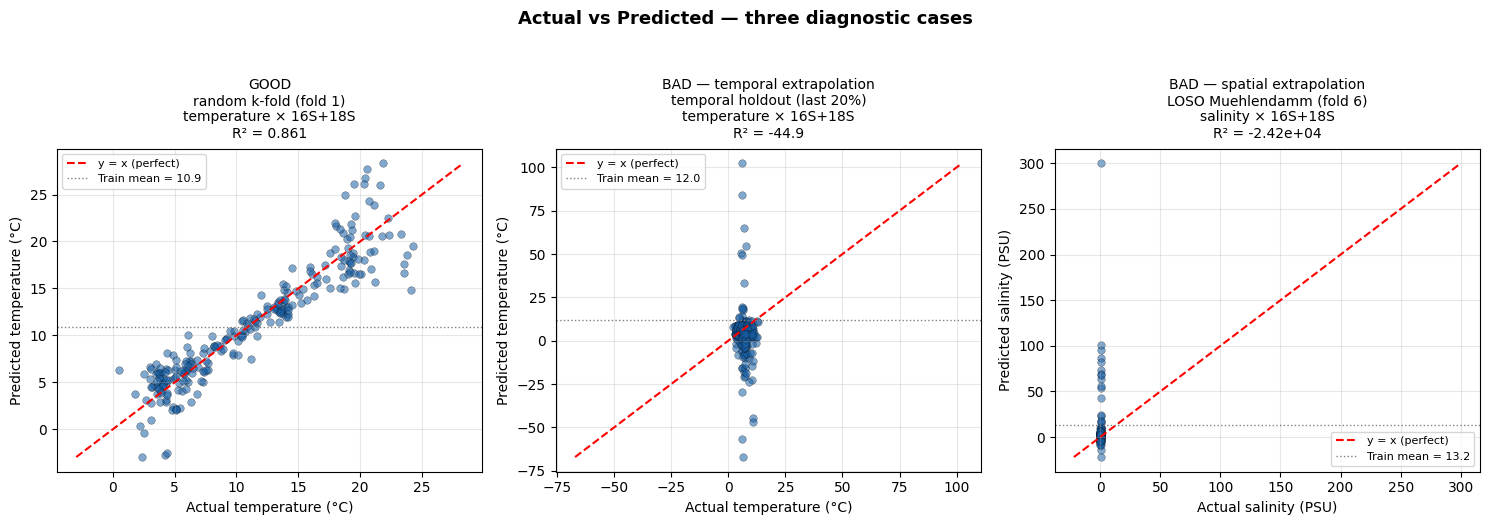

In [7]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

# Helper: fit a Lasso pipeline on a single train/test split and return predictions
def fit_predict_one_split(X_tr, y_tr, X_te, y_te, seed=42):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso',  LassoCV(cv=5, random_state=seed, max_iter=10_000, n_jobs=-1)),
    ])
    pipe.fit(X_tr, y_tr)
    y_hat = pipe.predict(X_te)
    return y_hat, r2_score(y_te, y_hat)

# Three diagnostic cases — one success, two failures
diagnostic_cases = [
    {
        'short_title': 'GOOD\nrandom k-fold (fold 1)\ntemperature × 16S+18S',
        'target_col':  'temperature',
        'otu':         otu_combined,
        'strategy':    'random_kfold',
        'fold_idx':    0,
        'unit':        '°C',
    },
    {
        'short_title': 'BAD — temporal extrapolation\ntemporal holdout (last 20%)\ntemperature × 16S+18S',
        'target_col':  'temperature',
        'otu':         otu_combined,
        'strategy':    'temporal_holdout',
        'fold_idx':    0,
        'unit':        '°C',
    },
    {
        'short_title': 'BAD — spatial extrapolation\nLOSO Muehlendamm (fold 6)\nsalinity × 16S+18S',
        'target_col':  'salinity',
        'otu':         otu_combined,
        'strategy':    'leave_one_site_out',
        'fold_idx':    5,   # Muehlendamm is the 6th site (0-indexed: 5)
        'unit':        'PSU',
    },
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, case in zip(axes, diagnostic_cases):
    print(f"Running: {case['short_title'].split(chr(10))[0]} ...")

    # Filter to valid samples for this target
    valid_mask = meta[case['target_col']].notna()
    meta_v = meta.loc[valid_mask].reset_index(drop=True)
    otu_v  = case['otu'].loc[valid_mask].reset_index(drop=True)
    X = otu_v.values
    y = meta_v[case['target_col']].values

    # Build splits with the same module the runs used
    if case['strategy'] == 'random_kfold':
        splits = random_kfold(len(meta_v), n_folds=5, random_seed=RANDOM_SEED)
    elif case['strategy'] == 'temporal_holdout':
        splits = temporal_holdout(meta_v, test_fraction=0.2)
    elif case['strategy'] == 'leave_one_site_out':
        splits = leave_one_site_out(meta_v)

    train_idx, test_idx = splits[case['fold_idx']]
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    y_hat, r2 = fit_predict_one_split(X_tr, y_tr, X_te, y_te, seed=RANDOM_SEED)
    print(f"   R² = {r2:.4f}    n_test = {len(y_te)}")

    # Scatter: actual on x-axis, predicted on y-axis
    ax.scatter(y_te, y_hat, alpha=0.55, s=30, edgecolor='black', linewidth=0.3, color='#185FA5')

    # y = x reference line (perfect prediction)
    lim_min = min(np.min(y_te), np.min(y_hat))
    lim_max = max(np.max(y_te), np.max(y_hat))
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1.5, label='y = x (perfect)')

    # Horizontal line at the training mean — shows where the model "defaults to" on bad data
    train_mean = np.mean(y_tr)
    ax.axhline(train_mean, color='gray', linestyle=':', linewidth=1.0,
               label=f'Train mean = {train_mean:.1f}')

    ax.set_xlabel(f"Actual {case['target_col']} ({case['unit']})", fontsize=10)
    ax.set_ylabel(f"Predicted {case['target_col']} ({case['unit']})", fontsize=10)
    ax.set_title(case['short_title'] + f"\nR² = {r2:.3g}", fontsize=10, pad=8)
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Actual vs Predicted — three diagnostic cases",
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()

out_path = Path("../results/phase1_diagnostic_scatter.png")
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"\nSaved figure: {out_path}")

plt.show()

In [1]:
import pandas as pd
from pathlib import Path

# Load per-site LOSO salinity table
csv_path = Path('~/tabpfn_project/results/loso_salinity_per_site_rf.csv').expanduser()
df = pd.read_csv(csv_path)
print(f"Loaded {len(df)} rows from {csv_path.name}")
print()

# Isolate brackish 13 (exclude Muehlendamm)
brackish = df[df['site_name'] != 'Muehlendamm']
print(f"Brackish sites: {len(brackish)}")
print()

# Compare mean vs median for each input
r2_cols = ['r2_16S', 'r2_18S', 'r2_16S+18S']
print(f"{'Input':<12}  {'Mean over 13':>15}  {'Median over 13':>15}  {'Diff':>10}")
print("-" * 60)
for col in r2_cols:
    m  = brackish[col].mean()
    md = brackish[col].median()
    print(f"{col:<12}  {m:>+15.4f}  {md:>+15.4f}  {m-md:>+10.4f}")

# Also show all 14 (including Muehlendamm) for reference
print()
print(f"{'Input':<12}  {'Mean over 14':>15}  {'Median over 14':>15}")
print("-" * 45)
for col in r2_cols:
    m  = df[col].mean()
    md = df[col].median()
    print(f"{col:<12}  {m:>+15.4f}  {md:>+15.4f}")

Loaded 14 rows from loso_salinity_per_site_rf.csv

Brackish sites: 13

Input            Mean over 13   Median over 13        Diff
------------------------------------------------------------
r2_16S                +0.8831          +0.9014     -0.0183
r2_18S                +0.8043          +0.8107     -0.0064
r2_16S+18S            +0.8803          +0.9073     -0.0270

Input            Mean over 14   Median over 14
---------------------------------------------
r2_16S               -26.3063          +0.8963
r2_18S               -60.1234          +0.8078
r2_16S+18S           -29.9356          +0.9060
